In [1]:
# Cell 1: Setup and imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

Libraries imported successfully
pandas: 2.2.0
numpy: 1.26.4


In [3]:
# Cell 2: Load the Silver layer data
import sys
import os
from pathlib import Path

# Set working directory to project root
project_root = Path().absolute().parent
os.chdir(project_root)
print(f"Working directory: {os.getcwd()}")

from src.data.ingest import load_hr_data
from src.data.clean import clean_hr_data

# Load raw and clean
df_raw = load_hr_data()
df = clean_hr_data(df_raw)

print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Working directory: c:\Users\nazmu\OneDrive\Desktop\smartpayroll-ai

Dataset shape: (1470, 33)
Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'TenureRatio', 'SatisfactionScore']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TenureRatio,SatisfactionScore
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,0,8,0,1,6,4,0,5,0.667,2.0
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,1,10,3,3,10,7,1,7,0.909,3.0
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,0,7,3,3,0,0,0,0,0.000,3.0


In [4]:
# Cell 3: Dataset overview
print("=" * 55)
print("SMARTPAYROLL HR DATASET — OVERVIEW")
print("=" * 55)
print(f"Rows:    {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"\nAttrition rate: {df['Attrition'].mean():.1%}")
print(f"  Stayed: {(df['Attrition']==0).sum():,} employees")
print(f"  Left:   {(df['Attrition']==1).sum():,} employees")
print(f"\nAge range: {df['Age'].min()} - {df['Age'].max()} years")
print(f"Salary range: ${df['MonthlyIncome'].min():,} - ${df['MonthlyIncome'].max():,}")
print(f"\nDepartments:")
print(df['Department'].value_counts().to_string())
print(f"\nNull values: {df.isnull().sum().sum()} ✅")

SMARTPAYROLL HR DATASET — OVERVIEW
Rows:    1,470
Columns: 33

Attrition rate: 16.1%
  Stayed: 1,233 employees
  Left:   237 employees

Age range: 18 - 60 years
Salary range: $1,009 - $19,999

Departments:
Department
Research & Development    961
Sales                     446
Human Resources            63

Null values: 0 ✅


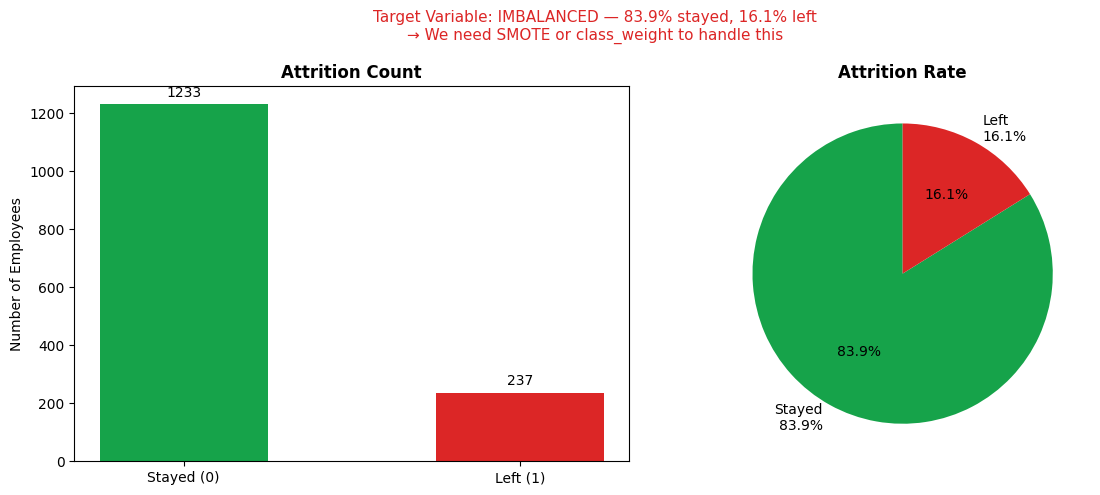

Chart saved to docs/


In [5]:
# Cell 4: Attrition distribution — our target variable
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Count bar chart
colors = ["#16A34A", "#DC2626"]
attrition_counts = df["Attrition"].value_counts()
bars = axes[0].bar(
    ["Stayed (0)", "Left (1)"],
    attrition_counts.values,
    color=colors,
    width=0.5
)
axes[0].bar_label(bars, fmt="%d", padding=3)
axes[0].set_title("Attrition Count", fontweight="bold")
axes[0].set_ylabel("Number of Employees")

# Right: Pie chart
axes[1].pie(
    attrition_counts.values,
    labels=[f"Stayed\n83.9%", f"Left\n16.1%"],
    colors=colors,
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Attrition Rate", fontweight="bold")

plt.suptitle(
    "Target Variable: IMBALANCED — 83.9% stayed, 16.1% left\n"
    "→ We need SMOTE or class_weight to handle this",
    fontsize=11, color="#DC2626"
)
plt.tight_layout()
plt.savefig("docs/eda_01_attrition.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to docs/")

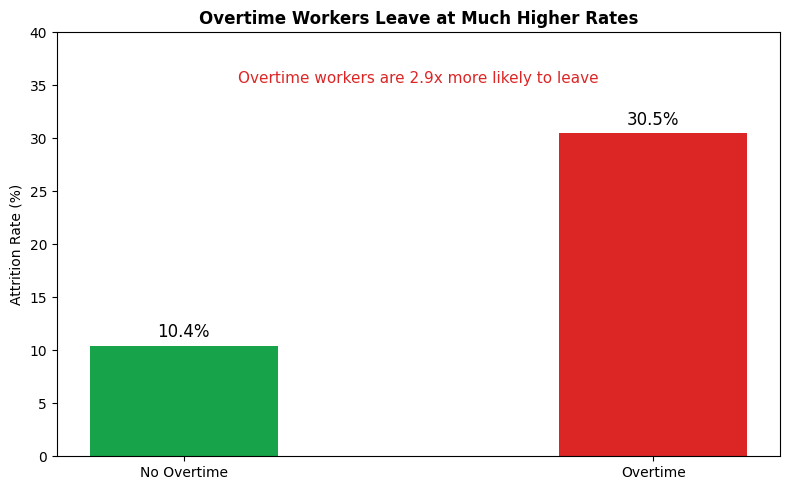

No overtime attrition: 10.4%
Overtime attrition:    30.5%
Overtime workers are 2.9x more likely to leave


In [6]:
# Cell 5: Overtime vs Attrition — the strongest predictor
fig, ax = plt.subplots(figsize=(8, 5))

overtime_attrition = df.groupby("OverTime")["Attrition"].mean() * 100

bars = ax.bar(
    ["No Overtime", "Overtime"],
    overtime_attrition.values,
    color=["#16A34A", "#DC2626"],
    width=0.4
)
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=12)
ax.set_ylabel("Attrition Rate (%)")
ax.set_title("Overtime Workers Leave at Much Higher Rates",
             fontweight="bold")
ax.set_ylim(0, 40)

no_ot = overtime_attrition[0]
ot = overtime_attrition[1]
multiplier = ot / no_ot

ax.text(0.5, 0.88,
        f"Overtime workers are {multiplier:.1f}x more likely to leave",
        transform=ax.transAxes,
        ha="center", fontsize=11,
        color="#DC2626")

plt.tight_layout()
plt.savefig("docs/eda_02_overtime.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"No overtime attrition: {no_ot:.1f}%")
print(f"Overtime attrition:    {ot:.1f}%")
print(f"Overtime workers are {multiplier:.1f}x more likely to leave")

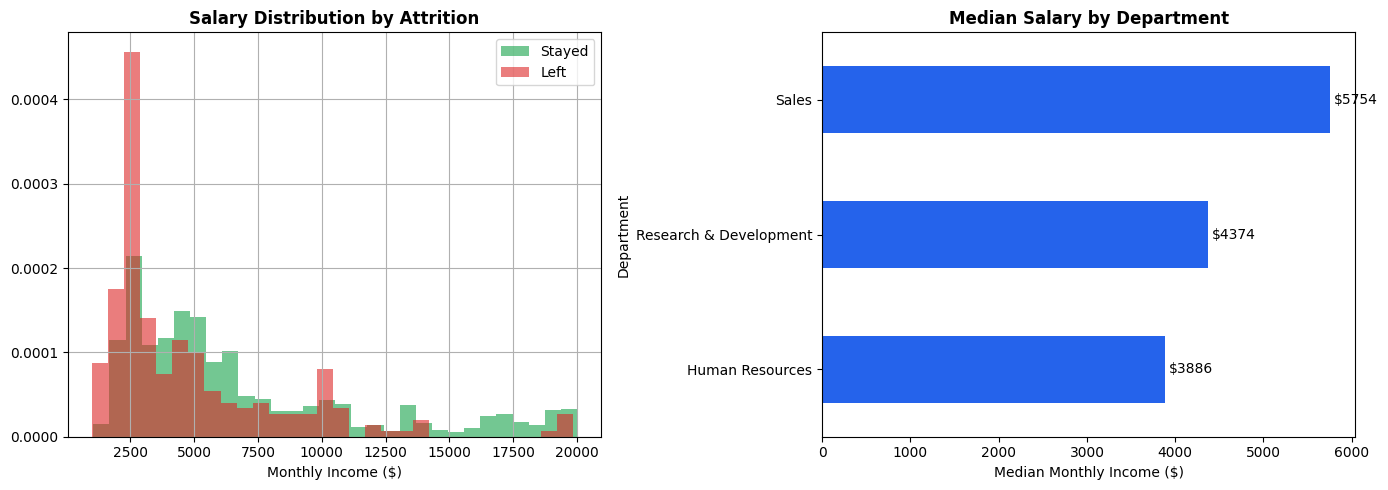

Median salary — Stayed: $5,204 | Left: $3,202
Difference: $2,002/month


In [7]:
# Cell 6: Salary distribution by attrition
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram
df[df["Attrition"]==0]["MonthlyIncome"].hist(
    bins=30, alpha=0.6, color="#16A34A",
    label="Stayed", ax=axes[0], density=True
)
df[df["Attrition"]==1]["MonthlyIncome"].hist(
    bins=30, alpha=0.6, color="#DC2626",
    label="Left", ax=axes[0], density=True
)
axes[0].set_xlabel("Monthly Income ($)")
axes[0].set_title("Salary Distribution by Attrition",
                   fontweight="bold")
axes[0].legend()

# Right: Box plot by department
dept_salary = df.groupby("Department")["MonthlyIncome"].median().sort_values()
dept_salary.plot(kind="barh", ax=axes[1], color="#2563EB")
axes[1].set_xlabel("Median Monthly Income ($)")
axes[1].set_title("Median Salary by Department",
                   fontweight="bold")
axes[1].bar_label(axes[1].containers[0], fmt="$%.0f", padding=3)

plt.tight_layout()
plt.savefig("docs/eda_03_salary.png", dpi=150, bbox_inches="tight")
plt.show()

stayed = df[df["Attrition"]==0]["MonthlyIncome"].median()
left = df[df["Attrition"]==1]["MonthlyIncome"].median()
print(f"Median salary — Stayed: ${stayed:,.0f} | Left: ${left:,.0f}")
print(f"Difference: ${stayed-left:,.0f}/month")

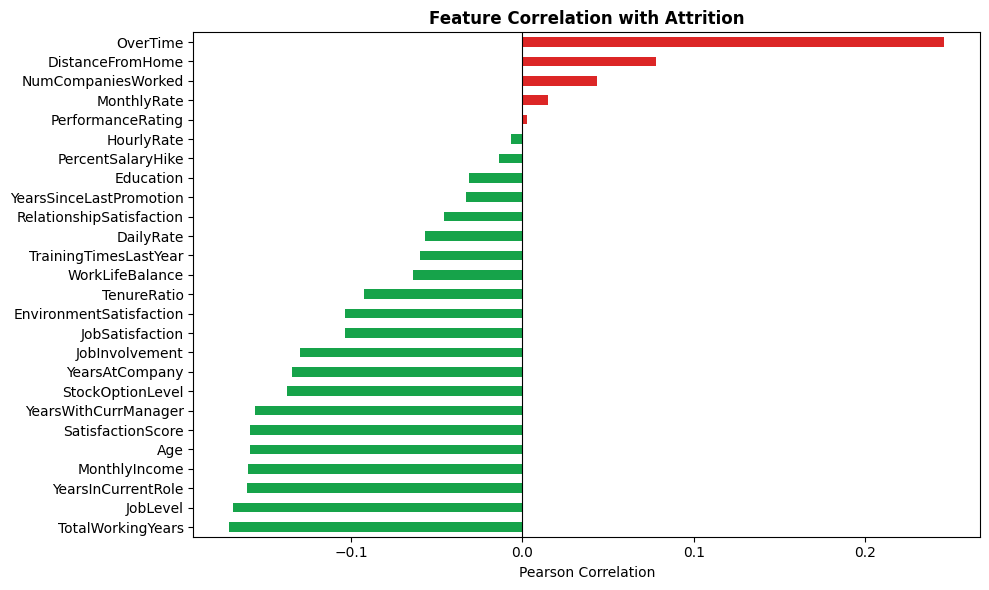

TOP 5 features most correlated with LEAVING:
PerformanceRating     0.002889
MonthlyRate           0.015170
NumCompaniesWorked    0.043494
DistanceFromHome      0.077924
OverTime              0.246118

TOP 5 features most correlated with STAYING:
TotalWorkingYears    -0.171063
JobLevel             -0.169105
YearsInCurrentRole   -0.160545
MonthlyIncome        -0.159840
Age                  -0.159205


In [8]:
# Cell 7: Correlation with Attrition
fig, ax = plt.subplots(figsize=(10, 6))

# Get numerical columns only
numerical_cols = df.select_dtypes(include=["number"]).columns.tolist()

# Correlation with Attrition specifically
attrition_corr = (
    df[numerical_cols]
    .corr()["Attrition"]
    .drop("Attrition")
    .sort_values()
)

# Colour: red = positive (more likely to leave), green = negative
colors = ["#DC2626" if v > 0 else "#16A34A" for v in attrition_corr.values]

attrition_corr.plot(kind="barh", ax=ax, color=colors)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_title("Feature Correlation with Attrition",
             fontweight="bold")
ax.set_xlabel("Pearson Correlation")

plt.tight_layout()
plt.savefig("docs/eda_04_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print("TOP 5 features most correlated with LEAVING:")
print(attrition_corr.tail(5).to_string())
print("\nTOP 5 features most correlated with STAYING:")
print(attrition_corr.head(5).to_string())

In [9]:
# Cell 8: Key findings summary
print("=" * 60)
print("SMARTPAYROLL EDA — KEY FINDINGS SUMMARY")
print("=" * 60)

findings = [
    ("Class Imbalance",
     "16.1% attrition — need SMOTE or class_weight for ML"),
    ("Overtime = #1 Risk",
     "Overtime workers 2.9x more likely to leave (30.5% vs 10.4%)"),
    ("Salary Gap",
     "Leavers earn $2,002/month less than stayers"),
    ("Experience Protects",
     "More total working years = lower attrition risk"),
    ("Job Level Matters",
     "Higher job level = more likely to stay"),
    ("Distance Effect",
     "Distance from home positively correlated with leaving"),
]

for i, (title, detail) in enumerate(findings, 1):
    print(f"\n  {i}. {title}")
    print(f"     → {detail}")

print("\n" + "=" * 60)
print("ML IMPLICATIONS:")
print("  → Use SMOTE for class imbalance")
print("  → Key features: OverTime, MonthlyIncome,")
print("                  TotalWorkingYears, JobLevel")
print("  → Use AUC-ROC and F1, NOT accuracy")
print("=" * 60)

SMARTPAYROLL EDA — KEY FINDINGS SUMMARY

  1. Class Imbalance
     → 16.1% attrition — need SMOTE or class_weight for ML

  2. Overtime = #1 Risk
     → Overtime workers 2.9x more likely to leave (30.5% vs 10.4%)

  3. Salary Gap
     → Leavers earn $2,002/month less than stayers

  4. Experience Protects
     → More total working years = lower attrition risk

  5. Job Level Matters
     → Higher job level = more likely to stay

  6. Distance Effect
     → Distance from home positively correlated with leaving

ML IMPLICATIONS:
  → Use SMOTE for class imbalance
  → Key features: OverTime, MonthlyIncome,
                  TotalWorkingYears, JobLevel
  → Use AUC-ROC and F1, NOT accuracy
